## Libraries and Imports

In [1]:
# Lets Import  (TeamRed: We are importing everything we need at the top)

# Data handling
import pandas as pd 
import numpy as np

# File and system handling
import os
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Machine learning: preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine learning: regression models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Machine learning: clustering
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

# Machine learning: anomaly detection
from sklearn.ensemble import IsolationForest

# Machine learning: evaluation
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import silhouette_score

# Model saving
import joblib


##### Set File Paths

In [2]:
# Set File Paths  (TeamRed: This is to help us avoid writing long file names everywhere)

DATA_DIR = Path("../data")

household_file = DATA_DIR / "peoplesun_hh_anon.csv"
appliance_file = DATA_DIR / "peoplesun_hhapps_anon.csv"
codebook_file = DATA_DIR / "peoplesun_hh_odk_codebook.xlsx"
choices_file = DATA_DIR / "peoplesun_hh_odk_choices.xlsx"
stoves_file = DATA_DIR / "peoplesun_hhstoves_anon.csv"
weather_file = DATA_DIR / "electricity_consumption_based_weather_dataset.csv"

##### Load Main Datasets

In [3]:
# Load the household and appliance datasets

hh_df = pd.read_csv(household_file, low_memory=False)
apps_df = pd.read_csv(appliance_file)

codebook_df = pd.read_excel(codebook_file)
choices_df = pd.read_excel(choices_file)

print("Datasets loaded successfully!")

Datasets loaded successfully!


##### Load Optional Supporting Datasets

In [4]:
stoves_df = pd.read_csv(stoves_file)
weather_df = pd.read_csv(weather_file)

print("Optional datasets loaded successfully!")

Optional datasets loaded successfully!


##### Inspect Dataset Shapes

In [17]:
# Check Dataset Shapes

print("Household dataset shape:", hh_df.shape)
print("Appliance dataset shape:", apps_df.shape)
print("Codebook shape:", codebook_df.shape)
print("Choices shape:", choices_df.shape)
print("Stoves dataset shape:", stoves_df.shape)
print("Weather dataset shape:", weather_df.shape)

Household dataset shape: (3599, 293)
Appliance dataset shape: (21594, 5)
Codebook shape: (121, 4)
Choices shape: (373, 3)
Stoves dataset shape: (21594, 5)
Weather dataset shape: (1433, 6)


In [18]:
# View household data
hh_df.head()

# View appliance data
apps_df.head()

# View codebook
codebook_df.head()

# View choices file
choices_df.head()

,list,name,label
0,yesnolist,1,Yes
1,yesnolist,0,No
2,optionlist,a,A
3,optionlist,b,B
4,rejectlist,1,No adult household member present


In [19]:
# Household column names
hh_df.columns.tolist()

# Appliance column names
apps_df.columns.tolist()



['hhid', 'q403', 'q403_1', 'q403_2', 'q403_3']

In [20]:
# Check missing values in household data
hh_df.isnull().sum().sort_values(ascending=False).head(20)

# Check missing values in appliance data
apps_df.isnull().sum()

hhid      0
q403      0
q403_1    0
q403_2    0
q403_3    0
dtype: int64

In [21]:
# Household column names
hh_df.columns.tolist()

# Appliance column names
apps_df.columns.tolist()



['hhid', 'q403', 'q403_1', 'q403_2', 'q403_3']

In [22]:
# Check missing values in household data
hh_df.isnull().sum().sort_values(ascending=False).head(20)

# Check missing values in appliance data
apps_df.isnull().sum()

hhid      0
q403      0
q403_1    0
q403_2    0
q403_3    0
dtype: int64

In [23]:
# Number of unique households in household dataset
print("Unique households in household dataset:", hh_df['hhid'].nunique())

# Number of unique households in appliance dataset
print("Unique households in appliance dataset:", apps_df['hhid'].nunique())

Unique households in household dataset: 3599
Unique households in appliance dataset: 3599


In [24]:
# Check the appliances recorded in the appliance dataset
apps_df['q403'].value_counts()

q403
Fan                     3599
Laptop / Computer       3599
Light bulb              3599
Mobile phone charger    3599
Radio                   3599
Television              3599
Name: count, dtype: int64

In [25]:
# TeamRed: This shows us that we can create useful appliance-based features from the dataset

 Data Visualization - Habiba 

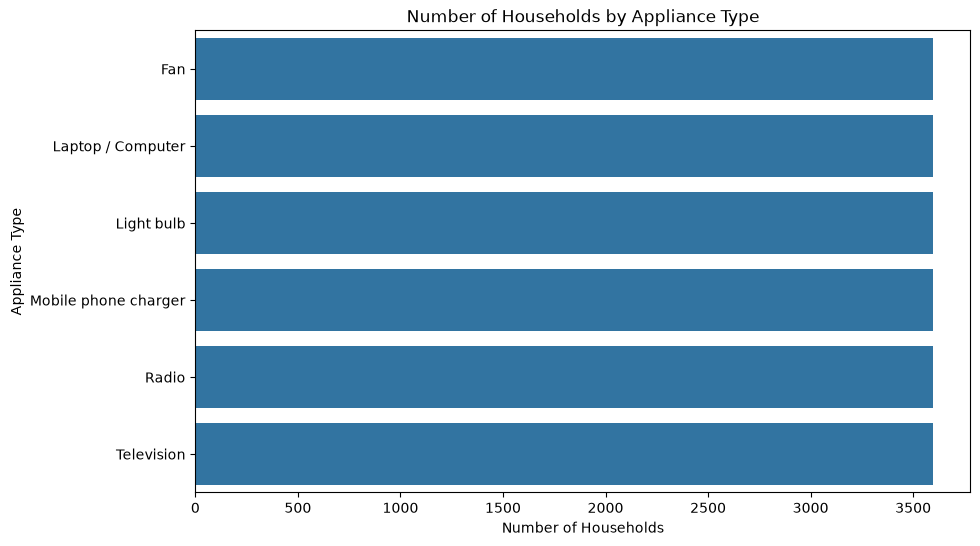

In [26]:
# Visualize the number of households recorded for each appliance

plt.figure(figsize=(10, 6))

sns.countplot(
        data=apps_df,
            y='q403',
                order=apps_df['q403'].value_counts().index
)

plt.title('Number of Households by Appliance Type')
plt.xlabel('Number of Households')
plt.ylabel('Appliance Type')

plt.show()


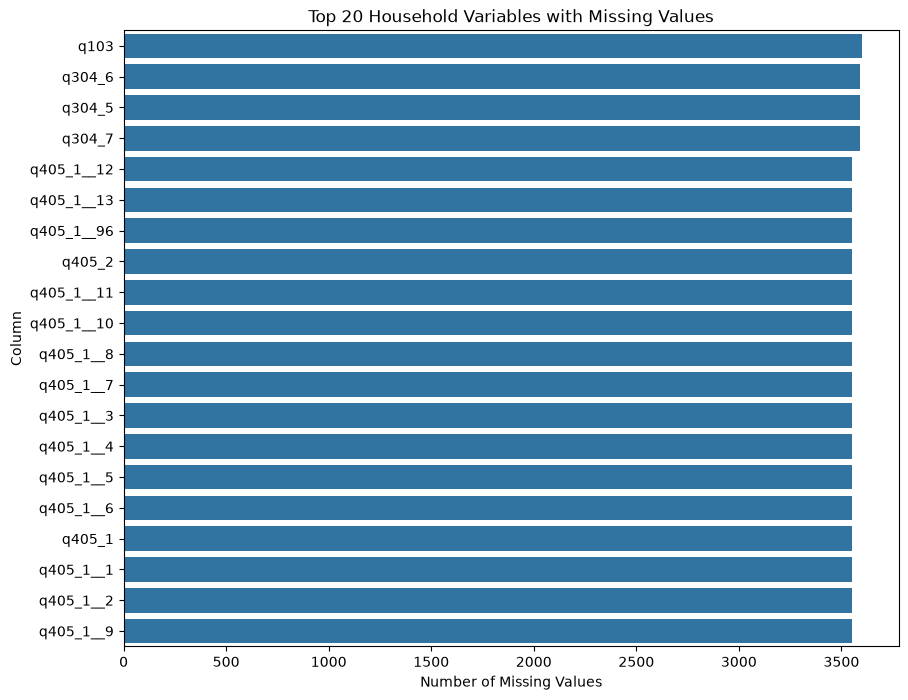

In [27]:
# Visualize the top 20 household columns with missing values

missing_values = (
        hh_df.isnull()
            .sum()
                .sort_values(ascending=False)
                    .head(20)
)

plt.figure(figsize=(10, 8))

sns.barplot(
        x=missing_values.values,
            y=missing_values.index
)

plt.title('Top 20 Household Variables with Missing Values')
plt.xlabel('Number of Missing Values')
plt.ylabel('Column')

plt.show()


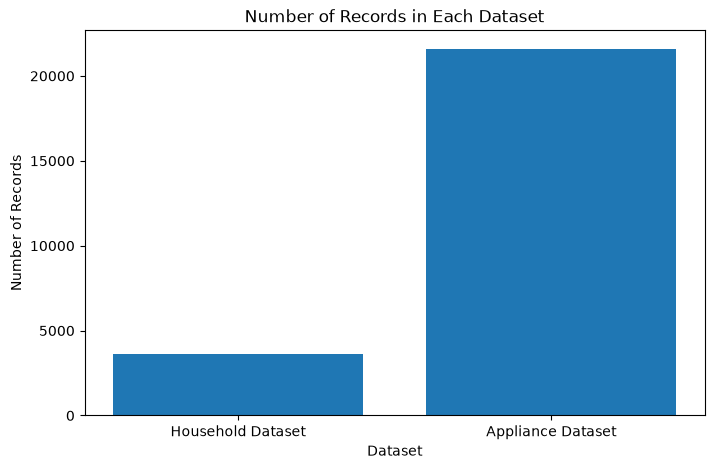

In [28]:
# Compare the number of records in the household and appliance datasets

dataset_sizes = {
        'Household Dataset': len(hh_df),
            'Appliance Dataset': len(apps_df)
}

plt.figure(figsize=(8, 5))

plt.bar(dataset_sizes.keys(), dataset_sizes.values())

plt.title('Number of Records in Each Dataset')
plt.xlabel('Dataset')
plt.ylabel('Number of Records')

plt.show()


 Observations

The appliance dataset contains six appliance categories, with each category appearing 3,599 times. This indicates that the six appliance records are consistently represented across the 3,599 households. 

The missing-value visualization highlights the household variables with the highest number of missing observations, which is useful for guiding future data cleaning an1d preprocessing.
 

The dataset size comparison compares the number the household and appliance datasets. The appliance dataset contains more records because each household has multiple appliance records associated with it. 

DATA VISUALIZATION - EBUBE

Distribution of Household Size
q102
1    3599
Name: count, dtype: int64


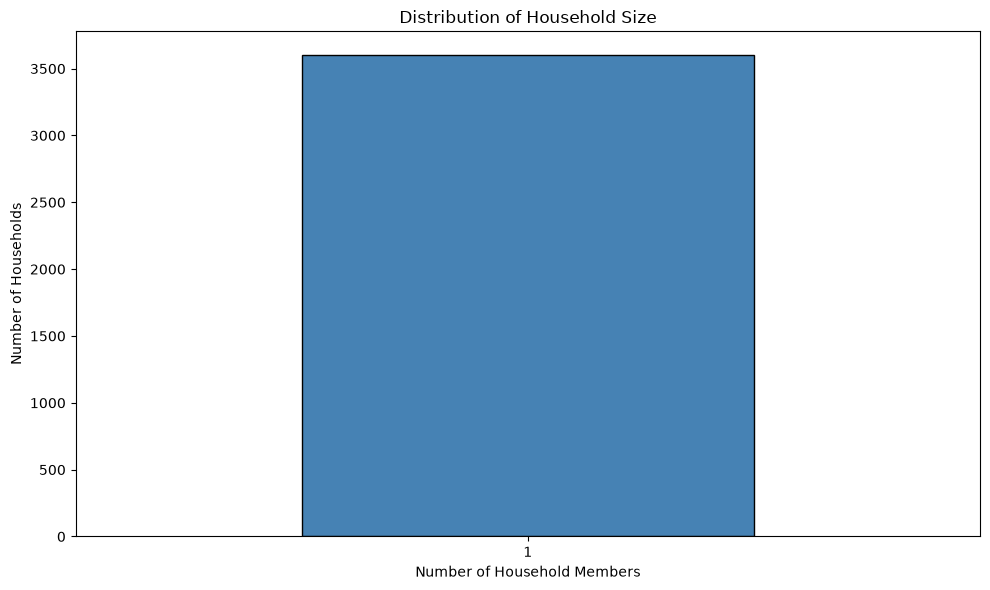

In [30]:

# Display the distribution of household size
household_size = hh_df['q102'].value_counts().sort_index()

# Print the values
print("Distribution of Household Size")
print(household_size)

# Create the bar chart
plt.figure(figsize=(10, 6))

household_size.plot(
    kind='bar',
    color='steelblue',
    edgecolor='black'
)

# Add chart title and labels
plt.title("Distribution of Household Size")
plt.xlabel("Number of Household Members")
plt.ylabel("Number of Households")

# Rotate x-axis labels for readability
plt.xticks(rotation=0)

# Improve layout
plt.tight_layout()

# Display the visualization
plt.show()